# Neural Network — MLP (PyTorch)
**NYC Airbnb Price Prediction | DS4420 Final Project | Meixu Chen, Yuetong Yin**

2-hidden-layer feedforward neural network built with PyTorch.  
Same features and train/val/test split as the OLS baseline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
Device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {Device}')

Device: cpu


## 1. Load & clean data 

In [2]:
df = pd.read_csv('nyc_listings.csv', low_memory=False)

cols = [
    'price', 'accommodates', 'bedrooms', 'bathrooms_text',
    'room_type', 'property_type', 'minimum_nights',
    'number_of_reviews', 'review_scores_rating', 'host_is_superhost',
    'neighbourhood_group_cleansed', 'latitude', 'longitude'
]
data = df[cols].copy()

data['price'] = pd.to_numeric(
    data['price'].astype(str).str.replace(r'[\$,]', '', regex=True).str.strip(),
    errors='coerce'
)
data['bathrooms'] = pd.to_numeric(
    data['bathrooms_text'].str.extract(r'(\d+\.?\d*)')[0], errors='coerce'
)
data = data.drop(columns='bathrooms_text')
data = data[
    data['price'].notna() & (data['price'] > 0) &
    (data['price'] < data['price'].quantile(0.99))
]

pt_counts = data['property_type'].value_counts()
data['property_type'] = data['property_type'].where(
    data['property_type'].isin(pt_counts[pt_counts >= 30].index), 'Other'
)
data = data.assign(
    review_scores_rating = data['review_scores_rating'].fillna(data['review_scores_rating'].median()),
    host_is_superhost    = data['host_is_superhost'].fillna('f'),
    bathrooms            = data['bathrooms'].fillna(data['bathrooms'].median()),
    bedrooms             = data['bedrooms'].fillna(data['bedrooms'].median()),
    log_price            = np.log(data['price'])
)
print(f'Dataset: {data.shape[0]:,} listings')

Dataset: 21,200 listings


## 2. Same split as OLS

In [3]:
train, temp = train_test_split(data, test_size=0.30, random_state=42)
val,   test = train_test_split(temp, test_size=0.50, random_state=42)
print(f'Train: {len(train):,} | Val: {len(val):,} | Test: {len(test):,}')

Train: 14,840 | Val: 3,180 | Test: 3,180


## 3. Feature engineering (manual)

In [4]:
NUM_FEATS = [
    'accommodates', 'bedrooms', 'bathrooms', 'minimum_nights',
    'number_of_reviews', 'review_scores_rating',
    'latitude', 'longitude'
]
CAT_FEATS = ['room_type', 'property_type', 'host_is_superhost', 'neighbourhood_group_cleansed']
TARGET    = 'log_price'


def make_X(df_split, num_feats, cat_feats,
           ohe_cols=None, means=None, stds=None):
    dummies = pd.get_dummies(df_split[cat_feats], drop_first=True)
    if ohe_cols is None:
        ohe_cols = dummies.columns.tolist()
    else:
        dummies = dummies.reindex(columns=ohe_cols, fill_value=0)

    X_num = df_split[num_feats].values.astype(float)
    if means is None:
        means = X_num.mean(axis=0)
        stds  = X_num.std(axis=0) + 1e-8

    X = np.hstack([(X_num - means) / stds, dummies.values.astype(float)])
    return X.astype(np.float32), ohe_cols, means, stds


X_tr, ohe_cols, means, stds = make_X(train, NUM_FEATS, CAT_FEATS)
X_va, *_                    = make_X(val,   NUM_FEATS, CAT_FEATS, ohe_cols, means, stds)
X_te, *_                    = make_X(test,  NUM_FEATS, CAT_FEATS, ohe_cols, means, stds)

y_tr = train[TARGET].values.astype(np.float32)
y_va = val[TARGET].values.astype(np.float32)
y_te = test[TARGET].values.astype(np.float32)

INPUT_DIM = X_tr.shape[1]
print(f'Input dimension: {INPUT_DIM}')

Input dimension: 39


## 4. DataLoaders

In [5]:
def to_loader(X, y, batch_size=256, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(1))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_tr, y_tr)
val_loader   = to_loader(X_va, y_va, shuffle=False)

## 5. Define MLP
Architecture: input -> 128 -> ReLU -> Dropout(0.2) -> 64 → ReLU -> Dropout(0.2) -> 1

In [6]:
class PriceNet(nn.Module):
    def __init__(self, input_dim, h1=128, h2=64, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(h1, h2),        nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(h2, 1)
        )
    def forward(self, x):
        return self.net(x)

model     = PriceNet(INPUT_DIM).to(Device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.MSELoss()
print(model)

PriceNet(
  (net): Sequential(
    (0): Linear(in_features=39, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


## 6. Training with early stopping

Epoch  20  train=0.5032  val=0.2174
Epoch  40  train=0.4329  val=0.1864
Epoch  60  train=0.3754  val=0.1791
Epoch  80  train=0.3307  val=0.1712
Epoch 100  train=0.2902  val=0.1819
Epoch 120  train=0.2628  val=0.1709
Epoch 140  train=0.2308  val=0.1683
Epoch 160  train=0.2092  val=0.1653
Epoch 180  train=0.1915  val=0.1627
Epoch 200  train=0.1815  val=0.1619


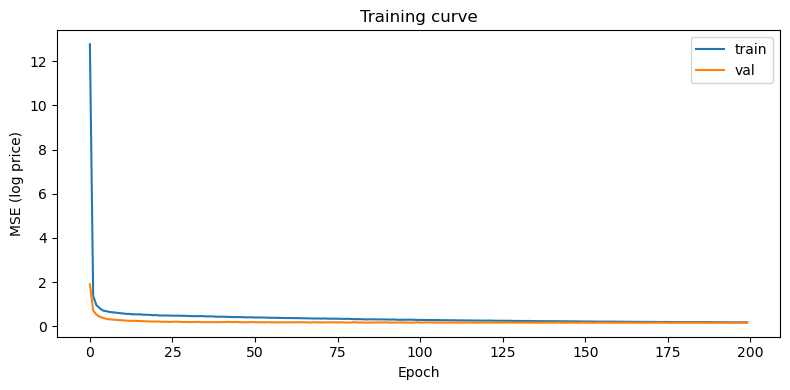

In [7]:
Epochs = 200
Patience = 15

train_losses, val_losses = [], []
best_val  = float('inf')
best_wts  = None
patience  = 0

for epoch in range(1, Epochs + 1):
    # train
    model.train()
    bl = []
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(Device), yb.to(Device)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        bl.append(loss.item())
    tl = np.mean(bl)

    # validate
    model.eval()
    with torch.no_grad():
        preds, targets = [], []
        for Xb, yb in val_loader:
            preds.append(model(Xb.to(Device)).cpu())
            targets.append(yb)
        vl = criterion(torch.cat(preds), torch.cat(targets)).item()

    train_losses.append(tl)
    val_losses.append(vl)

    if vl < best_val:
        best_val = vl
        best_wts = {k: v.clone() for k, v in model.state_dict().items()}
        patience = 0
    else:
        patience += 1
        if patience >= Patience:
            print(f'Early stopping at epoch {epoch}  (best val={best_val:.4f})')
            break

    if epoch % 20 == 0:
        print(f'Epoch {epoch:3d}  train={tl:.4f}  val={vl:.4f}')

model.load_state_dict(best_wts)

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='train')
plt.plot(val_losses,   label='val')
plt.xlabel('Epoch'); plt.ylabel('MSE (log price)')
plt.title('Training curve'); plt.legend()
plt.tight_layout(); plt.show()

## 7. Test evaluation

In [8]:
model.eval()
with torch.no_grad():
    y_pred_tr = model(torch.tensor(X_tr, dtype=torch.float32).to(Device)).cpu().numpy().flatten()
    y_pred_va = model(torch.tensor(X_va, dtype=torch.float32).to(Device)).cpu().numpy().flatten()
    y_pred_te = model(torch.tensor(X_te, dtype=torch.float32).to(Device)).cpu().numpy().flatten()

def metrics(y_true, y_pred, label=''):
    resid = y_true - y_pred
    mae   = np.mean(np.abs(resid))
    rmse  = np.sqrt(np.mean(resid**2))
    r2    = 1 - np.sum(resid**2) / np.sum((y_true - y_true.mean())**2)

    mae_p  = np.mean(np.abs(np.exp(y_true) - np.exp(y_pred)))
    rmse_p = np.sqrt(np.mean((np.exp(y_true) - np.exp(y_pred))**2))

    print(f'[{label}]  log MAE={mae:.4f}  RMSE={rmse:.4f}  R squre={r2:.4f}')
    print(f'            MAE={mae_p:.2f}  RMSE={rmse_p:.2f}')

    return dict(
        label=label,
        mae=mae,
        rmse=rmse,
        r2=r2,
        mae_price=mae_p,
        rmse_price=rmse_p,
        y_pred=y_pred,
        residuals=resid
    )

nn_train = metrics(y_tr, y_pred_tr, 'NN Train')
nn_val   = metrics(y_va, y_pred_va, 'NN Val')
nn_test  = metrics(y_te, y_pred_te, 'NN Test')

[NN Train]  log MAE=0.2857  RMSE=0.3825  R squre=0.7477
            MAE=63.99  RMSE=133.95
[NN Val]  log MAE=0.2976  RMSE=0.3985  R squre=0.7282
            MAE=76.53  RMSE=678.30
[NN Test]  log MAE=0.3009  RMSE=0.4054  R squre=0.7261
            MAE=71.94  RMSE=155.88


## 8. Predicted vs actual + residuals

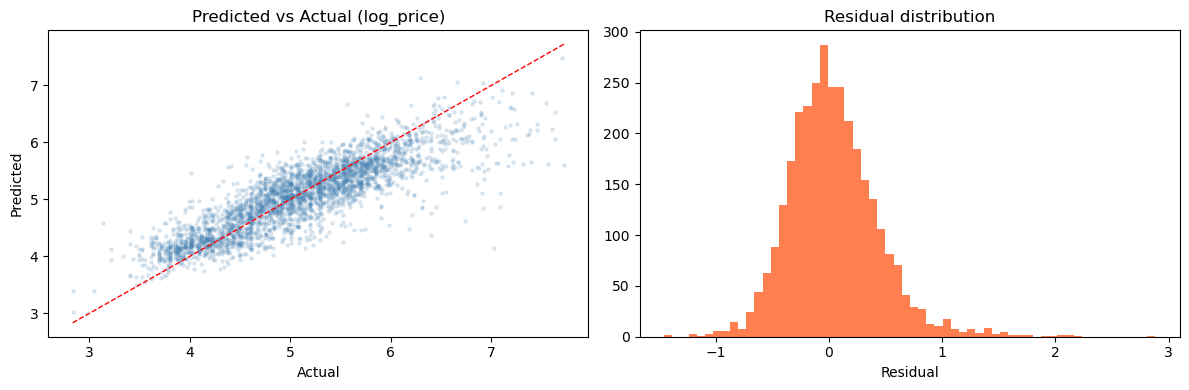

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_te, nn_test['y_pred'], alpha=0.15, s=5, color='steelblue')
mn, mx = y_te.min(), y_te.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1)
axes[0].set(title='Predicted vs Actual (log_price)', xlabel='Actual', ylabel='Predicted')

axes[1].hist(nn_test['residuals'], bins=60, color='coral', edgecolor='none')
axes[1].set(title='Residual distribution', xlabel='Residual')

plt.tight_layout()
plt.show()

In [10]:
splits = {
    'Train': nn_train,
    'Validation': nn_val,
    'Test': nn_test
}

nn_summary = pd.DataFrame(
    [{'Split': k, **v} for k, v in splits.items()]
)

nn_summary

,Split,label,mae,rmse,r2,mae_price,rmse_price,y_pred,residuals
0,Train,NN Train,0.285725,0.382533,0.747742,63.986977,133.949936,"[4.805931, 5.4639173, 4.846559, 4.667588, 5.59...","[0.19801521, 0.35912848, 0.42644072, 0.2668857..."
1,Validation,NN Val,0.297552,0.398505,0.728196,76.526810,678.299316,"[4.8158917, 4.893062, 5.353915, 5.7760925, 4.2...","[-0.6262369, 0.18211174, 0.1014061, 0.28769255..."
2,Test,NN Test,0.300852,0.405383,0.726077,71.944557,155.876816,"[4.4119167, 5.253159, 4.134931, 5.65362, 4.714...","[0.16279411, 0.14951849, 0.22177792, 0.4948487..."


## 9. Final metrics

In [11]:
print('Neural Network — Test Set')
print(f"MAE  (log scale):   {nn_test['mae']:.4f}")
print(f"RMSE (log scale):   {nn_test['rmse']:.4f}")
print(f"R squre:            {nn_test['r2']:.4f}")
print(f"MAE  (price scale): ${nn_test['mae_price']:.2f}")
print(f"RMSE (price scale): ${nn_test['rmse_price']:.2f}")

Neural Network — Test Set
MAE  (log scale):   0.3009
RMSE (log scale):   0.4054
R squre:            0.7261
MAE  (price scale): $71.94
RMSE (price scale): $155.88
